# Detect and Segment Laying Hens from an Image Frame

In [3]:
# import libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

In [4]:
# Load segmentation model
path = "/Users/ogbi/School/Research/poultry-vision/models/pen-seg-large.pt"
model = YOLO(path)


image 1/1 /Users/ogbi/School/Research/poultry-vision/sampleimages/poultry-test-3.jpg: 384x640 1 feeder, 10 hens, 1 waterer, 374.0ms
Speed: 6.5ms preprocess, 374.0ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)


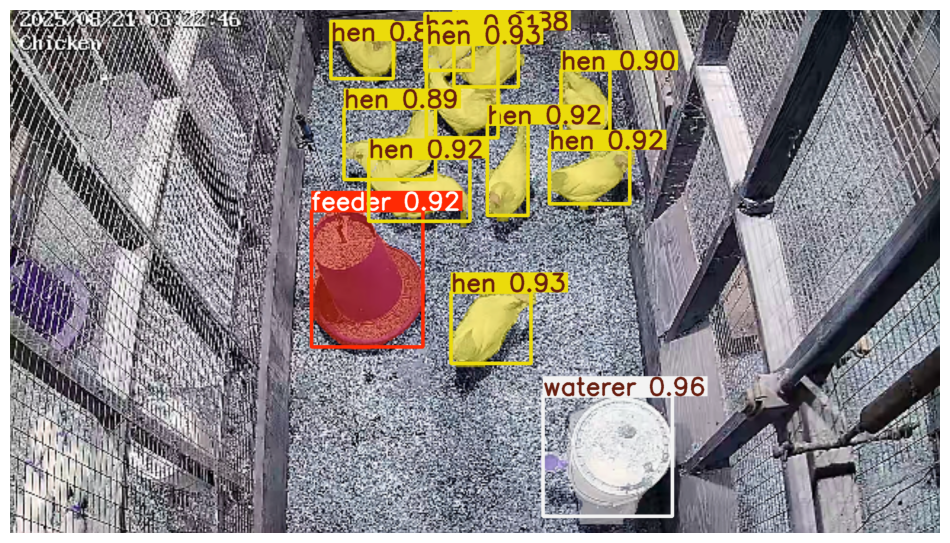

In [6]:
# segment all hens with the pen segmentation model
# d(id) = {'hen', 'feeder', 'drinker}
image_path = "/Users/ogbi/School/Research/poultry-vision/sampleimages/poultry-test-3.jpg"
results = model(image_path)

# show image
image_path = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(image_path)
plt.axis('off')
plt.show()

In [10]:
# Explore raw segmentation output
print("=== Results Object Structure ===")
print(f"Type: {type(results)}")
print(f"Length: {len(results)}")
print(f"\n=== First Result ===")
result = results[0]
print(f"Result attributes: {dir(result)}")


=== Results Object Structure ===
Type: <class 'list'>
Length: 1

=== First Result ===
Result attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_keys', 'boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save', 'save_crop', 'save_dir', 'save_txt', 'show', 'speed', 'summary', 'to', 'to_csv', 'to_df', 'to_json', 'to_xml', 'tojson', 'update', 'verbose']


In [11]:
# Access segmentation masks and boxes
import numpy as np

result = results[0]

print("=== Detection Boxes ===")
if result.boxes is not None:
    print(f"Number of detections: {len(result.boxes)}")
    print(f"Boxes shape: {result.boxes.xyxy.shape}")  # (N, 4) - top-left and bottom-right coords
    print(f"Confidence scores shape: {result.boxes.conf.shape}")
    print(f"Class IDs shape: {result.boxes.cls.shape}")
    print(f"\nFirst detection:")
    print(f"  Box coords (xyxy): {result.boxes.xyxy[0]}")
    print(f"  Confidence: {result.boxes.conf[0]}")
    print(f"  Class ID: {int(result.boxes.cls[0])}")

print("\n=== Segmentation Masks ===")
if result.masks is not None:
    print(f"Number of masks: {len(result.masks)}")
    print(f"Mask shape: {result.masks.data.shape}")  # (N, H, W) - binary masks
    print(f"First mask size: {result.masks.data[0].shape}")
    print(f"Mask dtype: {result.masks.data.dtype}")
    print(f"Mask value range: [{result.masks.data.min()}, {result.masks.data.max()}]")

print("\n=== Class Names ===")
print(f"Class names: {result.names}")


=== Detection Boxes ===
Number of detections: 12
Boxes shape: torch.Size([12, 4])
Confidence scores shape: torch.Size([12])
Class IDs shape: torch.Size([12])

First detection:
  Box coords (xyxy): tensor([1102.0031,  799.4073, 1366.4938, 1047.2358])
  Confidence: 0.9476157426834106
  Class ID: 2

=== Segmentation Masks ===
Number of masks: 12
Mask shape: torch.Size([12, 384, 640])
First mask size: torch.Size([384, 640])
Mask dtype: torch.float32
Mask value range: [0.0, 1.0]

=== Class Names ===
Class names: {0: 'feeder', 1: 'hen', 2: 'waterer'}


IndexError: index 6 is out of bounds for axis 0 with size 6

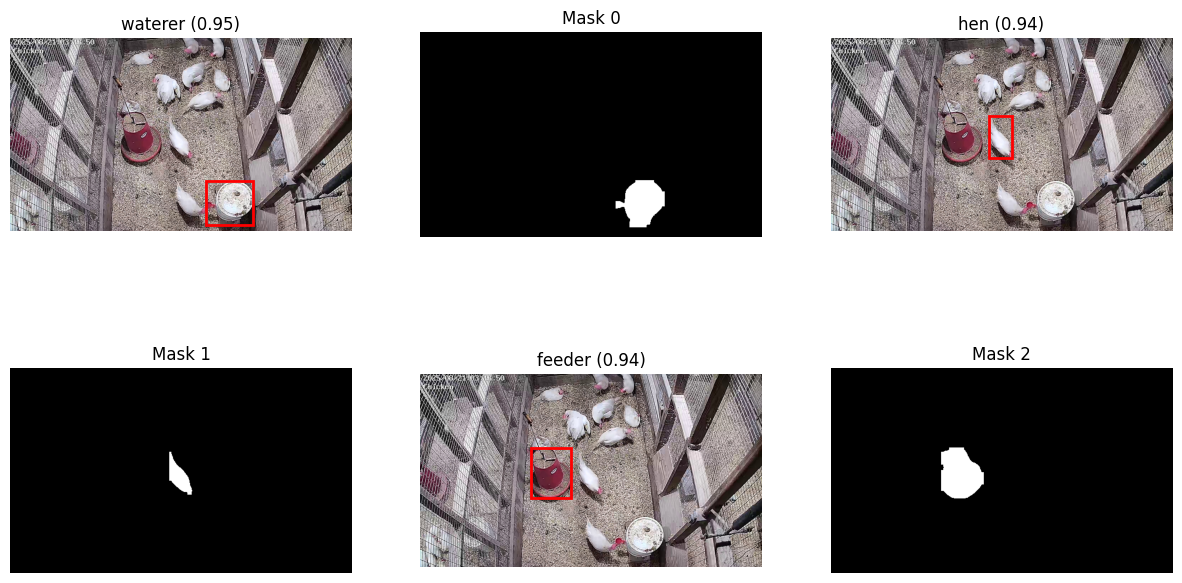

In [13]:
# Visualize individual masks and extract metadata
import matplotlib.patches as patches

result = results[0]
original_image = cv2.imread(result.path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Create subplots for each detection
if result.masks is not None:
    num_detections = len(result.masks)
    fig, axes = plt.subplots(2, min(3, num_detections), figsize=(15, 8))
    axes = axes.flatten()
    
    for idx in range(min(num_detections, 6)):
        # Show original with bounding box
        ax = axes[idx * 2]
        ax.imshow(original_image)
        
        # Draw bounding box
        box = result.boxes.xyxy[idx].cpu().numpy()
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                  linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
        class_id = int(result.boxes.cls[idx])
        conf = result.boxes.conf[idx]
        ax.set_title(f"{result.names[class_id]} ({conf:.2f})")
        ax.axis('off')
        
        # Show mask
        ax = axes[idx * 2 + 1]
        mask = result.masks.data[idx].cpu().numpy()
        ax.imshow(mask, cmap='gray')
        ax.set_title(f"Mask {idx}")
        ax.axis('off')
    
    # Hide unused subplots
    for ax in axes[min(num_detections, 6) * 2:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Extract all metadata as a table
print("\n=== Detection Summary ===")
for idx in range(len(result.boxes)):
    box = result.boxes.xyxy[idx].cpu().numpy()
    conf = result.boxes.conf[idx].cpu().item()
    class_id = int(result.boxes.cls[idx])
    class_name = result.names[class_id]
    mask_area = int(result.masks.data[idx].sum().item()) if result.masks else 0
    
    print(f"Detection {idx}: {class_name}")
    print(f"  Confidence: {conf:.4f}")
    print(f"  Box (xyxy): [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]")
    print(f"  Box size: {box[2]-box[0]:.1f} x {box[3]-box[1]:.1f} pixels")
    print(f"  Mask area: {mask_area} pixels")
